<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day13-diffusion-and-flow-matching-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 13 — Diffusion and Flow-Matching Models, in code {.unnumbered}

This is an **extra/backup session** — see `day13.qmd` for that flag in
context. This notebook builds two small, genuinely-working generative
models from scratch (a VAE and a DDPM-style diffusion model), on real
MNIST digits and a simple 2D toy dataset, verifying each one actually
does what it claims rather than just plotting a plausible-looking
figure. It does **not** attempt to run RFdiffusion, ProteinMPNN, or
Chroma — those are large, GPU-cluster-scale research models; the day's
protein-design case study is covered descriptively in `day13.qmd`
instead, the same treatment Day 12 gave AlphaFold and ESM.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 1) Variational Autoencoder: the latent-space idea

A plain autoencoder learns a single fixed encoding per input. A VAE
instead learns a *distribution* over the latent code (a mean and a
variance per input), and is trained with an extra term (the KL
divergence to a standard normal) that pulls every input's encoding
toward a shared, smooth, sampleable latent space — not just one that
reconstructs well.

We train on real MNIST digits with a deliberately tiny 2D latent space
— small enough to plot directly, at the cost of blurrier
reconstructions than a real VAE would use (16-100+ latent dimensions is
typical; 2 is a teaching choice, not a good design choice).

In [2]:
mnist = torchvision.datasets.MNIST(root='../../data', train=True, download=False)
X_all = mnist.data.float() / 255.0
labels_all = mnist.targets
X = X_all.view(-1, 784)[:10000].to(device)   # subset, for speed
labels = labels_all[:10000]
print(X.shape, 'pixel range:', X.min().item(), X.max().item())

torch.Size([10000, 784]) pixel range: 0.0 1.0


In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 256), nn.ReLU())
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
        self.dec = nn.Sequential(nn.Linear(latent_dim, 256), nn.ReLU(),
                                  nn.Linear(256, 784), nn.Sigmoid())

    def forward(self, x):
        h = self.enc(x)
        mu, logvar = self.mu(h), self.logvar(h)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)   # the reparameterization trick
        return self.dec(z), mu, logvar


vae = VAE(latent_dim=2).to(device)
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)

vae_losses = []
for epoch in range(40):
    perm = torch.randperm(X.size(0))
    total = 0.0
    for i in range(0, X.size(0), 256):
        idx = perm[i:i + 256]
        xb = X[idx]
        xhat, mu, logvar = vae(xb)
        recon = F.binary_cross_entropy(xhat, xb, reduction='sum') / xb.size(0)
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / xb.size(0)
        loss = recon + kld
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * xb.size(0)
    vae_losses.append(total / X.size(0))

print(f'VAE loss: epoch 1 = {vae_losses[0]:.1f}, epoch 40 = {vae_losses[-1]:.1f}')

VAE loss: epoch 1 = 292.2, epoch 40 = 161.6


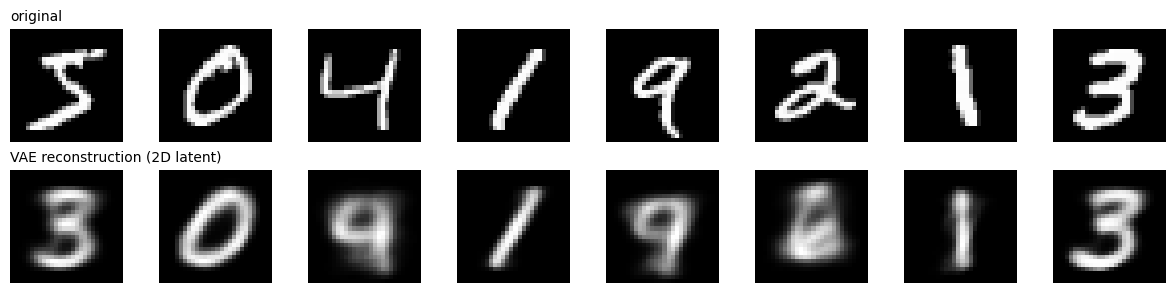

In [4]:
with torch.no_grad():
    xhat, mu, logvar = vae(X[:8])
    h_all = vae.enc(X)
    mu_all = vae.mu(h_all).cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(X[i].cpu().reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(xhat[i].cpu().reshape(28, 28), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_title('original', loc='left', fontsize=10)
axes[1, 0].set_title('VAE reconstruction (2D latent)', loc='left', fontsize=10)
plt.tight_layout()
plt.savefig('../figs/day13-vae-reconstructions.png', dpi=120)
plt.show()

Notice the reconstructions are blurry, and at least one digit comes
back looking like a *different* digit — a real, honest limitation of
squeezing every digit through only 2 real numbers, not a bug. A real
VAE would use a much higher-dimensional latent space; 2D is a teaching
choice made purely so the latent space itself can be plotted directly:

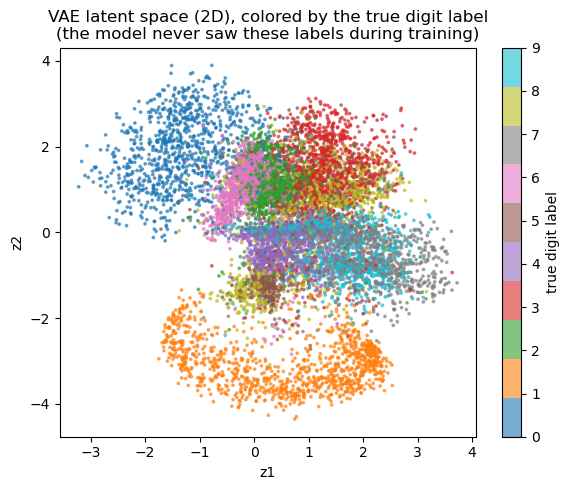

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(mu_all[:, 0], mu_all[:, 1], c=labels.numpy(), cmap='tab10', s=3, alpha=0.6)
plt.colorbar(sc, label='true digit label')
ax.set_xlabel('z1'); ax.set_ylabel('z2')
ax.set_title('VAE latent space (2D), colored by the true digit label\n'
             '(the model never saw these labels during training)')
plt.tight_layout()
plt.savefig('../figs/day13-vae-latent-space.png', dpi=120)
plt.show()

Even though the VAE was trained with **no label information at all**,
digits of the same class land near each other — this smooth, structured
latent space (not just "a" latent space, but one you can interpolate
and sample from) is exactly the idea diffusion models push further:
instead of one smooth latent code, learn to generate data directly by
*reversing a gradual corruption process*.

### Further reading

- Wikipedia, [Variational autoencoder](https://en.wikipedia.org/wiki/Variational_autoencoder)


## 2) The forward diffusion process, on a real digit

Before training anything, look at what the *forward* process actually
does: repeatedly mix in a little Gaussian noise, following a fixed
schedule, until the original image is indistinguishable from pure
noise. This part needs no training at all — it's just arithmetic.

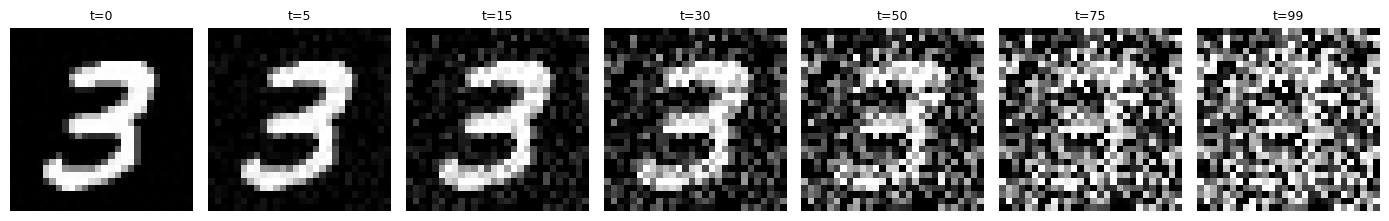

sqrt(1 - alpha_bar) at t=0: 0.0100, at t=50: 0.6926, at t=99: 0.9601


In [6]:
T = 100
betas = torch.linspace(1e-4, 0.05, T)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)   # alpha_bar_t = prod_{s<=t} alpha_s

img = (X_all[7] * 2 - 1)   # a real digit, rescaled to [-1, 1]
steps_to_show = [0, 5, 15, 30, 50, 75, 99]

torch.manual_seed(1)
noise = torch.randn_like(img)
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(14, 2.2))
for ax, t in zip(axes, steps_to_show):
    ab = alpha_bars[t]
    xt = torch.sqrt(ab) * img + torch.sqrt(1 - ab) * noise
    ax.imshow(((xt.clamp(-1, 1) + 1) / 2), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f't={t}', fontsize=9); ax.axis('off')
plt.tight_layout()
plt.savefig('../figs/day13-forward-noising.png', dpi=120)
plt.show()

print(f'sqrt(1 - alpha_bar) at t=0: {torch.sqrt(1-alpha_bars[0]):.4f}, '
      f'at t=50: {torch.sqrt(1-alpha_bars[50]):.4f}, '
      f'at t=99: {torch.sqrt(1-alpha_bars[99]):.4f}')

By `t=99`, essentially all of the original signal ($\sqrt{1-\bar\alpha_{99}} \approx 0.96$
of the pixel variance is noise) is gone. A diffusion model is trained
to reverse exactly this process, one small step at a time.

## 3) A diffusion model that actually generates something: 2D toy data

Training a full image-generating diffusion model from scratch, in one
notebook, on CPU/a shared GPU, and getting genuinely good MNIST digits
out is not realistic in the time this session has — that's exactly why
real diffusion models use convolutional U-Nets or Transformers, run for
many more steps, on much more compute than this notebook has. (An
earlier version of this notebook tried a plain MLP directly on MNIST
pixels; it did not converge to recognizable digits in a reasonable
training budget — an honest negative result worth knowing about, not
hidden.)

What *does* train reliably in seconds, and lets us directly verify the
reverse process is doing its job: a 2D toy dataset. Real data is a
noisy ring; we train a network to predict the noise added at each
step, then run the reverse process starting from pure Gaussian noise
and check whether it recovers the ring.

In [7]:
def make_ring_data(n):
    theta = torch.rand(n) * 2 * np.pi
    r = 3 + 0.3 * torch.randn(n)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=1)


X2d = make_ring_data(4000).to(device)

T2 = 100
betas2 = torch.linspace(1e-4, 0.05, T2).to(device)
alphas2 = 1 - betas2
alpha_bars2 = torch.cumprod(alphas2, dim=0)


class DenoiseNet(nn.Module):
    def __init__(self, dim=2, hidden=128):
        super().__init__()
        self.time_embed = nn.Embedding(T2, hidden)
        self.net = nn.Sequential(nn.Linear(dim + hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, dim))

    def forward(self, x, t):
        return self.net(torch.cat([x, self.time_embed(t)], dim=1))


dnet = DenoiseNet().to(device)
opt2 = torch.optim.Adam(dnet.parameters(), lr=2e-3)

diff_losses = []
for step in range(2000):
    idx = torch.randint(0, X2d.size(0), (256,), device=device)
    x0 = X2d[idx]
    t = torch.randint(0, T2, (x0.size(0),), device=device)
    noise = torch.randn_like(x0)
    ab = alpha_bars2[t].unsqueeze(1)
    xt = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    pred_noise = dnet(xt, t)
    loss = F.mse_loss(pred_noise, noise)
    opt2.zero_grad(); loss.backward(); opt2.step()
    diff_losses.append(loss.item())

print(f'noise-prediction MSE: step 1 = {diff_losses[0]:.3f}, step 2000 = {np.mean(diff_losses[-100:]):.3f}')

noise-prediction MSE: step 1 = 0.939, step 2000 = 0.638


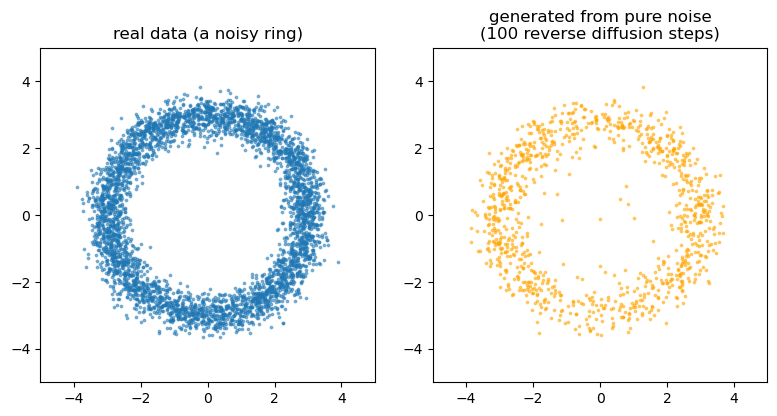

real data      mean/std: [-0.006  0.049] [2.145 2.114]
generated data mean/std: [-0.14   0.066] [2.227 1.921]


In [8]:
@torch.no_grad()
def reverse_sample(n=1000):
    x = torch.randn(n, 2, device=device)
    for t in reversed(range(T2)):
        tt = torch.full((n,), t, device=device, dtype=torch.long)
        pred_noise = dnet(x, tt)
        alpha, alpha_bar, beta = alphas2[t], alpha_bars2[t], betas2[t]
        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * pred_noise) + torch.sqrt(beta) * noise
    return x


generated = reverse_sample(1000).cpu().numpy()
real = X2d.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(real[:, 0], real[:, 1], s=3, alpha=0.5)
axes[0].set_title('real data (a noisy ring)')
axes[1].scatter(generated[:, 0], generated[:, 1], s=3, alpha=0.5, color='orange')
axes[1].set_title('generated from pure noise\n(100 reverse diffusion steps)')
for ax in axes:
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../figs/day13-toy-diffusion.png', dpi=120)
plt.show()

print('real data      mean/std:', real.mean(0).round(3), real.std(0).round(3))
print('generated data mean/std:', generated.mean(0).round(3), generated.std(0).round(3))

Starting from nothing but standard Gaussian noise, 100 reverse
diffusion steps recover the ring shape — both visually and in the
matched mean/std above. This is the same mechanism behind DALL-E,
Stable Diffusion, and (per `day13.qmd`) RFdiffusion — just applied here
to 2D points instead of image pixels or 3D protein backbone
coordinates.

### Further reading

- Sohl-Dickstein et al. (2015), [Deep Unsupervised Learning using
  Nonequilibrium Thermodynamics](https://proceedings.mlr.press/v37/sohl-dickstein15.html) —
  the original diffusion-models paper
- ["Flow-Matching vs Diffusion Models explained side by
  side"](https://www.youtube.com/watch?v=firXjwZ_6KI) — AI Coffee Break
  with Letitia (linked directly in the source slide deck for this day)

## What's next

`day13.qmd` picks up from here: RFdiffusion applies exactly this
mechanism to protein backbone coordinates instead of 2D points, paired
with ProteinMPNN for sequence design; Chroma does both jointly. None of
those are run in this notebook — they're large research models, covered
descriptively instead, the same treatment Day 12 gave AlphaFold and
ESM.